<a href="https://colab.research.google.com/github/2403A52058/NLP_LABASSIGNMENTS/blob/main/NLP_LAB12_4_textcnn_pretrainedEmbeddings_S_koushik_2403a52058.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [27]:
# Import required libraries

import numpy as np
import pandas as pd
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Check device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


Load and Explore Dataset

In [28]:
# Load dataset (SMS Spam dataset)

data = pd.read_csv('/content/data.txt', sep='\t', header=None, names=['label', 'message'])

# Display first 5 rows
data.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Text Preprocessing

In [29]:
# Text cleaning function
def clean_text(text):
    text = text.lower()                      # convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation/numbers
    text = text.strip()
    return text

# Apply cleaning
data['message'] = data['message'].apply(clean_text)

# Convert labels to numeric
data['label'] = data['label'].map({'ham':0, 'spam':1})


Vocabulary and Embedding Preparation

In [30]:
# Tokenization
def tokenize(text):
    return text.split()

data['tokens'] = data['message'].apply(tokenize)

# Build vocabulary
vocab = {}
for tokens in data['tokens']:
    for word in tokens:
        if word not in vocab:
            vocab[word] = len(vocab) + 1   # start from 1 (0 for padding)

vocab_size = len(vocab) + 1
print("Vocabulary Size:", vocab_size)


Vocabulary Size: 8630


In [31]:
max_len = 50  # maximum sequence length

def encode(tokens):
    encoded = [vocab[word] for word in tokens if word in vocab]
    if len(encoded) < max_len:
        encoded += [0] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]
    return encoded

data['encoded'] = data['tokens'].apply(encode)


In [33]:
# Download GloVe 100d embeddings
!wget http://nlp.stanford.edu/data/glove.6B.zip

# Unzip file
!unzip glove.6B.zip


--2026-02-19 04:25:47--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-02-19 04:25:47--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-02-19 04:25:48--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

Load Pretrained GloVe Embeddings

In [34]:
embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))

with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        if word in vocab:
            idx = vocab[word]
            embedding_matrix[idx] = vector

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)


Train Test Split

In [35]:
X = np.array(data['encoded'].tolist())
y = np.array(data['label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.long).to(device)
X_test = torch.tensor(X_test, dtype=torch.long).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)


Define 1D CNN Model

In [47]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embedding_matrix):
        super(TextCNN, self).__init__()

        # Pretrained embedding
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=False
        )

        # Multiple convolution layers
        self.conv3 = nn.Conv1d(embedding_dim, 128, kernel_size=3)
        self.conv4 = nn.Conv1d(embedding_dim, 128, kernel_size=4)
        self.conv5 = nn.Conv1d(embedding_dim, 128, kernel_size=5)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(128 * 3, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        conv3 = self.relu(self.conv3(x))
        conv4 = self.relu(self.conv4(x))
        conv5 = self.relu(self.conv5(x))

        pool3 = torch.max(conv3, dim=2)[0]
        pool4 = torch.max(conv4, dim=2)[0]
        pool5 = torch.max(conv5, dim=2)[0]

        concat = torch.cat((pool3, pool4, pool5), dim=1)
        concat = self.dropout(concat)

        out = self.fc(concat)
        return self.sigmoid(out)


Initialize Model

In [37]:
model = TextCNN(vocab_size, embedding_dim, embedding_matrix).to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Training

In [42]:
batch_size = 64

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

epochs = 10
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        outputs = model(xb).squeeze()
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")


Epoch 1/10, Loss: 0.2529
Epoch 2/10, Loss: 0.0946
Epoch 3/10, Loss: 0.0504
Epoch 4/10, Loss: 0.0312
Epoch 5/10, Loss: 0.0200
Epoch 6/10, Loss: 0.0125
Epoch 7/10, Loss: 0.0087
Epoch 8/10, Loss: 0.0066
Epoch 9/10, Loss: 0.0051
Epoch 10/10, Loss: 0.0042


Training Loss Graph

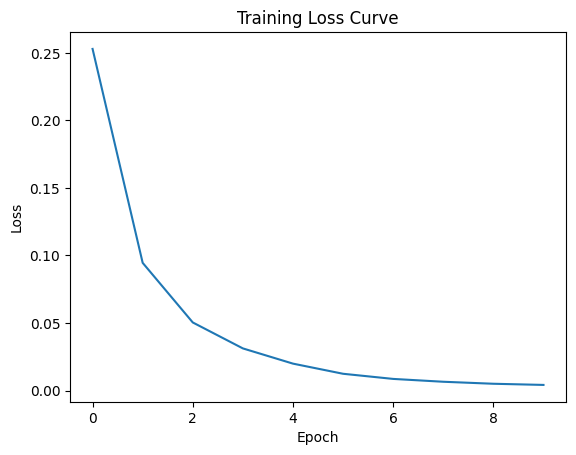

In [48]:
plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()


Evaluation

In [49]:
model.eval()
with torch.no_grad():
    preds = model(X_test).squeeze()
    preds = (preds > 0.5).float()

accuracy = accuracy_score(y_test.cpu(), preds.cpu())
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test.cpu(), preds.cpu()))


Accuracy: 0.9847533632286996

Classification Report:

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99       966
         1.0       0.98      0.91      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



Confusion Matrix Graph

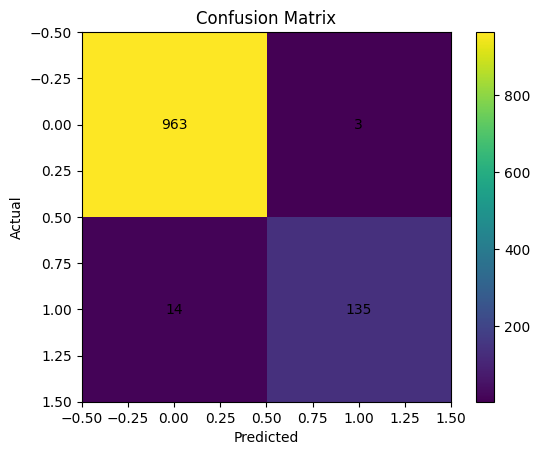

In [50]:
cm = confusion_matrix(y_test.cpu(), preds.cpu())

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()
